In [38]:
%matplotlib inline

# `skreducedmodel` package basics and testing

| Attribute                   | What it contains                                            |
| --------------------------- | ----------------------------------------------------------- |
| `rb.tree.basis`             | Array of basis vectors (shape: N_basis × N_samples)         |
| `rb.tree.indices`           | Indices of training set waveforms used as greedy picks      |
| `rb.tree.errors`            | Max greedy error after each basis vector                    |
| `rb.tree.train_parameters`  | All training parameters at this node (useful for reference) |
| `rb.tree.projection_matrix` | Matrix of projections of basis vectors onto training set    |


In [2]:
import sys
from pathlib import Path

# Add project root to Python path
sys.path.append(str(Path.cwd().parent))

from generate_greedy_training_set import *

/home/suzanne/anaconda3/envs/phenomxpy/lib/python3.10/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


You do not have pyseobnr installed


/home/suzanne/anaconda3/envs/phenomxpy/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


lal.MSUN_SI != Msun


In [3]:
from skreducedmodel.reducedbasis import ReducedBasis
from skreducedmodel.empiricalinterpolation import EmpiricalInterpolation
from skreducedmodel.surrogate import Surrogate

In [4]:
sampling_frequency = 2048 # or 4096
duration = 4 # seconds
time_array = np.linspace(-duration, 0, int(sampling_frequency * duration))  # time in seconds
print(f'time-array: [{round(SecondtoMass(time_array, 60)[0], 2)}, {round(SecondtoMass(time_array, 60)[-1], 2)}] seconds, with {len(time_array)} points')
ecc_ref_parameterspace=np.linspace(0.001, 0.1, num=200)

gt = Generate_TrainingSet(time_array=time_array, ecc_ref_parameterspace=ecc_ref_parameterspace, mean_ano_parameterspace=[0], N_basis_vecs_amp=20, N_basis_vecs_phase=20,
                          minimum_spacing_greedy=0.003 )
res_ds_phase = gt.generate_property_dataset(property='phase', ecc_ref_list=ecc_ref_parameterspace, plot_residuals_time_evolv=True, plot_residuals_eccentric_evolv=True, show_legend=False)
res_ds_amp = gt.generate_property_dataset(property='amplitude', ecc_ref_list=ecc_ref_parameterspace, plot_residuals_time_evolv=True, plot_residuals_eccentric_evolv=True, show_legend=False)


time-array: [-13535.03, 0.0] seconds, with 8192 points
[0.001      0.00149749 0.00199497 0.00249246 0.00298995 0.00348744
 0.00398492 0.00448241 0.0049799  0.00547739 0.00597487 0.00647236
 0.00696985 0.00746734 0.00796482 0.00846231 0.0089598  0.00945729
 0.00995477 0.01045226 0.01094975 0.01144724 0.01194472 0.01244221
 0.0129397  0.01343719 0.01393467 0.01443216 0.01492965 0.01542714
 0.01592462 0.01642211 0.0169196  0.01741709 0.01791457 0.01841206
 0.01890955 0.01940704 0.01990452 0.02040201 0.0208995  0.02139698
 0.02189447 0.02239196 0.02288945 0.02338693 0.02388442 0.02438191
 0.0248794  0.02537688 0.02587437 0.02637186 0.02686935 0.02736683
 0.02786432 0.02836181 0.0288593  0.02935678 0.02985427 0.03035176
 0.03084925 0.03134673 0.03184422 0.03234171 0.0328392  0.03333668
 0.03383417 0.03433166 0.03482915 0.03532663 0.03582412 0.03632161
 0.0368191  0.03731658 0.03781407 0.03831156 0.03880905 0.03930653
 0.03980402 0.04030151 0.04079899 0.04129648 0.04179397 0.04229146
 0.0427

In [5]:
sampling_frequency = 2048 # or 4096
duration = 4 # seconds
time_array = np.linspace(-duration, 0, int(sampling_frequency * duration))  # time in seconds
print(f'time-array: [{round(SecondtoMass(time_array, 60)[0], 2)}, {round(SecondtoMass(time_array, 60)[-1], 2)}] seconds, with {len(time_array)} points')
ecc_ref_parameterspace=np.linspace(0.001, 0.1, num=200)

gt = Generate_TrainingSet(time_array=time_array, ecc_ref_parameterspace=ecc_ref_parameterspace, N_basis_vecs_amp=20, N_basis_vecs_phase=20,
                          minimum_spacing_greedy=0.003 )
res_ds_phase = gt.generate_property_dataset(property='phase')
res_ds_amp = gt.generate_property_dataset(property='amplitude')


time-array: [-13535.03, 0.0] seconds, with 8192 points
Mean anomaly values wrapped into range [0, 2π).
[0.001      0.00149749 0.00199497 0.00249246 0.00298995 0.00348744
 0.00398492 0.00448241 0.0049799  0.00547739 0.00597487 0.00647236
 0.00696985 0.00746734 0.00796482 0.00846231 0.0089598  0.00945729
 0.00995477 0.01045226 0.01094975 0.01144724 0.01194472 0.01244221
 0.0129397  0.01343719 0.01393467 0.01443216 0.01492965 0.01542714
 0.01592462 0.01642211 0.0169196  0.01741709 0.01791457 0.01841206
 0.01890955 0.01940704 0.01990452 0.02040201 0.0208995  0.02139698
 0.02189447 0.02239196 0.02288945 0.02338693 0.02388442 0.02438191
 0.0248794  0.02537688 0.02587437 0.02637186 0.02686935 0.02736683
 0.02786432 0.02836181 0.0288593  0.02935678 0.02985427 0.03035176
 0.03084925 0.03134673 0.03184422 0.03234171 0.0328392  0.03333668
 0.03383417 0.03433166 0.03482915 0.03532663 0.03582412 0.03632161
 0.0368191  0.03731658 0.03781407 0.03831156 0.03880905 0.03930653
 0.03980402 0.04030151 0.0

## Non-normalised, non-weighted
### Reduced basis

For non-normalised greedy error, the absolute error for waveform \(f_i\) is:

$$
\varepsilon_i^{\rm abs} = \| f_i - P_N f_i \|
$$

where $P_N f_i$ is the projection of $f_i$ onto the current basis.

- Here, the error scales with the waveform amplitude.
- The algorithm will naturally favour waveforms with larger L2 norms.

**The non-normalised error prefers high-eccentric waveform vectors**, because the amplitude of high-eccentric cases is much higher, so the absolute difference for these cases will seem much larger compared to the low-eccentric ones. 

**Usecase:**  
Use this method if you prefer to minimize the absolute msimatch in the final waveform reconstruction


In [6]:
rb_amp = ReducedBasis(greedy_tol=1e-9, normalize=False, nmax=100)

rb_amp.fit(training_set = res_ds_amp,
       parameters = ecc_ref_parameterspace,
       physical_points = gt.time
       )

rb_phase = ReducedBasis(greedy_tol=1e-5, normalize=False, nmax=100)
rb_phase.fit(training_set = res_ds_phase,
       parameters = ecc_ref_parameterspace,
       physical_points = gt.time
       )

amplitude_indices = rb_amp.tree.indices   # indices of training set waveforms chosen as greedy anchors
phase_indices = rb_phase.tree.indices

amplitude_parameters = ecc_ref_parameterspace[amplitude_indices]
phase_parameters = ecc_ref_parameterspace[phase_indices]

print(len(rb_amp.tree.indices), len(rb_phase.tree.indices))

24 46


In [7]:
plt.figure(figsize=(20,3))
plt.plot(ecc_ref_parameterspace, np.zeros(len(ecc_ref_parameterspace)), label='eccentricity parameter space', lw=1.8, color='gray')
plt.scatter(amplitude_parameters, np.zeros(len(amplitude_parameters)), label='greedy parameters for amplitude', color='red', s=20)
plt.xlabel('eccentricity')
plt.legend()

plt.figure(figsize=(20,3))
plt.plot(ecc_ref_parameterspace, np.zeros(len(ecc_ref_parameterspace)), label='eccentricity parameter space', lw=1.8, color='gray')
plt.scatter(phase_parameters, np.zeros(len(phase_parameters)), label='greedy parameters for phase', color='blue', s=20)
plt.xlabel('eccentricity')
plt.legend()


In [8]:
amplitude_errors = rb_amp.tree.errors
phase_errors = rb_phase.tree.errors

print("Max amplitude error:", np.max(amplitude_errors))
print("Max phase error:", np.max(phase_errors))

plt.figure(figsize=(12,3))
plt.plot(np.arange(len(amplitude_errors)), amplitude_errors, label='greedy error for amplitude', lw=1.8, color='red')
plt.xlabel('# of greedy vectors')
plt.legend()

plt.figure(figsize=(12,3))
plt.plot(np.arange(len(phase_errors)), phase_errors, label='greedy error for phase', lw=1.8, color='blue')
plt.xlabel('# of greedy vectors')
plt.legend()

Max amplitude error: 0.5097930891309514
Max phase error: 226964.50759560766


### Emperical interpolation

In [9]:
def get_empirical_nodes(reduced_basis_object):
    eim = EmpiricalInterpolation(reduced_basis_object)
    eim.fit()

    # print('Amount of leaves in reduced basis tree:', len(reduced_basis_object.tree.leaves))
    dir(reduced_basis_object.tree.leaves[0])

    for i in range(len(reduced_basis_object.tree.leaves)):
        emp_nodes_idx = reduced_basis_object.tree.leaves[i].empirical_nodes
        emp_nodes_idx = np.array(emp_nodes_idx).astype(int)
    
        print('Empirical nodes:', emp_nodes_idx,
            '\nlength of empirical nodes:', len(emp_nodes_idx),
            '\nlength of reduced basis:', len(reduced_basis_object.tree.leaves[i].indices)) # .indices refers to the indices of the greedy basis vectors
        
    return emp_nodes_idx, reduced_basis_object

emp_nodes_idx_phase, rb_phase = get_empirical_nodes(rb_phase)
print('\n')
emp_nodes_idx_amp, rb_amp = get_empirical_nodes(rb_amp)


Empirical nodes: [ 124 7966 3050  218 6500 6567  169 6411 6540 8132 7598 6434 6381 7692
 6077  284 8134 6460 6617 7722 6518  956 8137 8087 8080 7757 8135 6477
 8075 6584 6359 7635 6299  513  665 6757  340 8119 6821 8133 8120 1661
 6446 1962 5889 8121] 
length of empirical nodes: 46 
length of reduced basis: 46


Empirical nodes: [  21  298 2182  161  207 8085 8140 7602  121 8134  255 8089 5970 8132
 7647 7732 8077 8094 8082 8074 8136  362 6438 6412] 
length of empirical nodes: 24 
length of reduced basis: 24


In [10]:
def plot_interpolation_matrix(reduced_basis_object):
    reduced_basis = reduced_basis_object.tree.leaves[0].basis # ORTHONORMALIZED basis functions 
    eim_nodes = reduced_basis_object.tree.leaves[0].empirical_nodes # indices of empirical nodes

    # Interpolation matrix: V_{ij} = φ_i(t_j)
    V = reduced_basis[:, eim_nodes]

    fig, ax = plt.subplots(figsize=(6,5))

    im = ax.imshow(V, aspect='auto', origin='lower')

    ax.set_title("EIM interpolation matrix")
    ax.set_xlabel("Empirical node index")
    ax.set_ylabel("Basis index")

    fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

    return V

V_phase = plot_interpolation_matrix(rb_phase)
V_amp = plot_interpolation_matrix(rb_amp)

print(np.linalg.cond(V_phase))
print(np.linalg.cond(V_amp))

77.31803533197109
50.669213781339145


In [11]:
def plot_projection_error_vs_eim_error(reduced_basis_object, dataset):
    reduced_basis = reduced_basis_object.tree.leaves[0].basis # ORTHONORMALIZED basis functions 
    eim_nodes = reduced_basis_object.tree.leaves[0].empirical_nodes

    proj_errors = []
    eim_errors = []

    for k in range(1, len(eim_nodes) + 1):
        basis_k = reduced_basis[:k]                        # (k, n_time)
        nodes_k = eim_nodes[:k]

        # EIM interpolation operator, matching your implementation
        V_k = np.array([[basis_k[m, t] for t in nodes_k] for m in range(k)])
        invVt_k = np.linalg.inv(V_k.T)
        interpolant_k = basis_k.T @ invVt_k              # (n_time, k)

        max_proj_err = 0.0
        max_eim_err = 0.0

        for f in dataset:
            # --- Best projection onto span(basis_k) ---
            # Solve min ||f - c @ basis_k||
            coeff_proj = basis_k @ f
            f_proj = basis_k.T @ coeff_proj

            proj_err = np.linalg.norm(f - f_proj) / np.linalg.norm(f)
            max_proj_err = max(max_proj_err, proj_err)

            # --- EIM reconstruction from node values only ---
            f_nodes = f[nodes_k]
            f_eim = interpolant_k @ f_nodes

            eim_err = np.linalg.norm(f - f_eim) / np.linalg.norm(f)
            max_eim_err = max(max_eim_err, eim_err)

        proj_errors.append(max_proj_err)
        eim_errors.append(max_eim_err)
    plt.figure(figsize=(7,4))
    plt.semilogy(range(1, len(eim_nodes)+1), proj_errors, marker='o', label='Projection error')
    plt.semilogy(range(1, len(eim_nodes)+1), eim_errors, marker='s', label='EIM error')
    plt.xlabel("Number of modes / EIM nodes")
    plt.ylabel("Max relative error")
    plt.title("Projection error vs EIM error")
    plt.grid(True)
    plt.legend()

    return proj_errors, eim_errors

proj_errors_phase, eim_errors_phase = plot_projection_error_vs_eim_error(rb_phase, res_ds_phase)
proj_errors_amp, eim_errors_amp = plot_projection_error_vs_eim_error(rb_amp, res_ds_amp)

In [12]:
def plot_error_ratio(reduced_basis_object, proj_errors, eim_errors):
    ratio = np.array(eim_errors) / np.array(proj_errors)

    plt.figure(figsize=(7,4))
    plt.semilogy(range(1, len(reduced_basis_object.tree.leaves[0].empirical_nodes)+1), ratio, marker='o')
    plt.xlabel("Number of modes / EIM nodes")
    plt.ylabel("EIM error / Projection error")
    plt.title("Interpolation overhead relative to best basis approximation")
    plt.grid(True)

plot_error_ratio(rb_phase, proj_errors_phase, eim_errors_phase)
plot_error_ratio(rb_amp, proj_errors_amp, eim_errors_amp)


In [13]:
def plot_eim_nodes_on_waveforms(reduced_basis_object, dataset):
    emp_nodes_idx = reduced_basis_object.tree.leaves[0].empirical_nodes

    fig_eim =plt.figure(figsize=(12,4))

    plt.scatter(gt.time[emp_nodes_idx],dataset[-1][emp_nodes_idx], label='empirical nodes', color='blue')
    plt.plot(gt.time, dataset[-1], label='phase/amplitude at max eccentricity', lw=1.8, color='gray')
    plt.xlabel('time [M]')
    plt.ylabel('phase [rad] OR amplitude')

    plt.legend()
    plt.tight_layout()

plot_eim_nodes_on_waveforms(rb_phase, res_ds_phase)
plot_eim_nodes_on_waveforms(rb_amp, res_ds_amp)

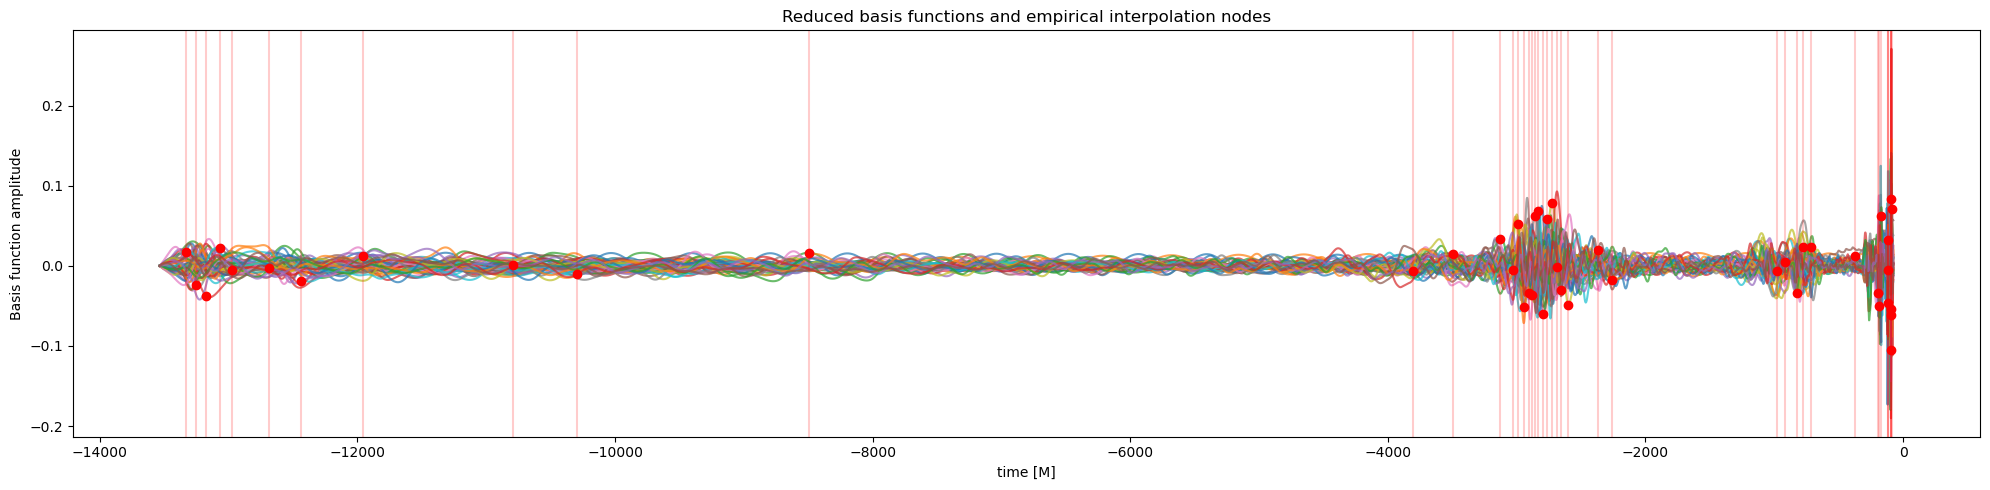

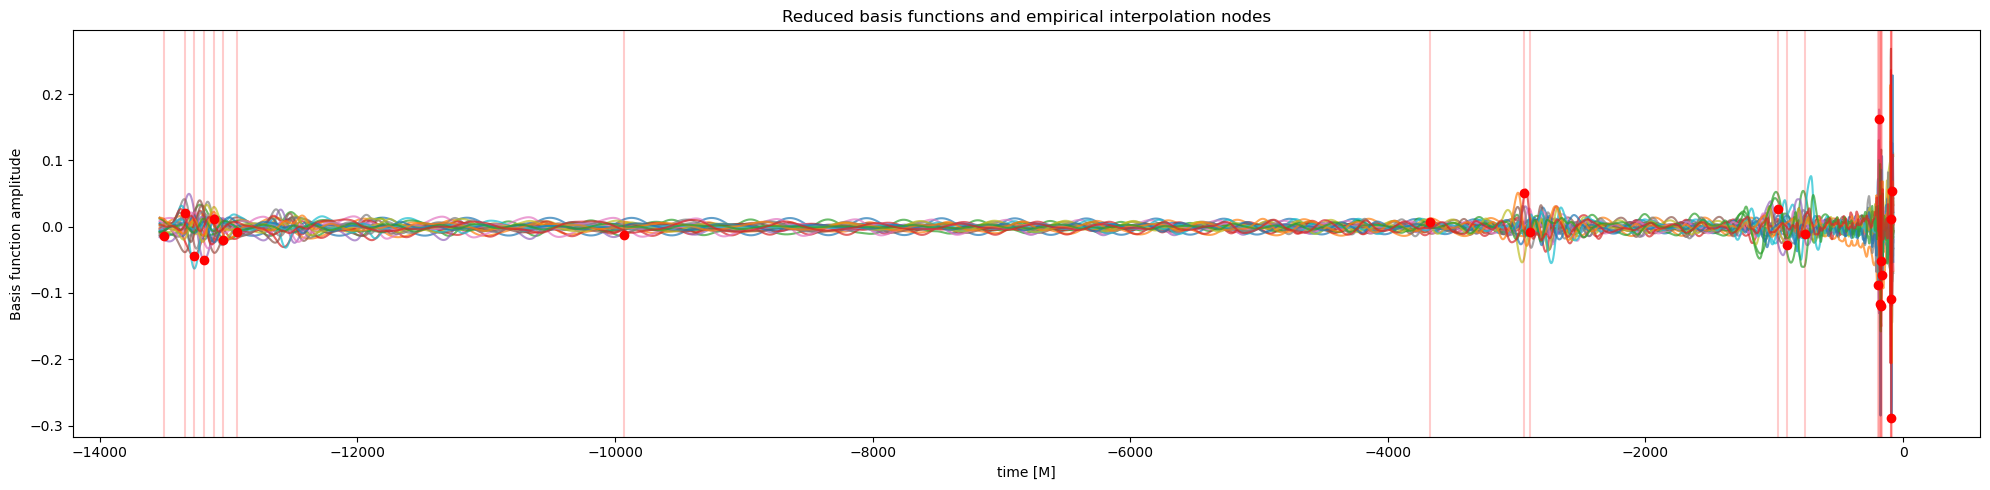

In [43]:
def plot_nodes_on_rb_functions(reduced_basis_object, time):

    for leaf in reduced_basis_object.tree.leaves:
        reduced_basis = leaf.basis # ORTHONORMALIZED basis functions
        eim_nodes = leaf.empirical_nodes

        fig, ax = plt.subplots(figsize=(20,5))

        # Plot basis functions
        for i in range(len(eim_nodes)):
            ax.plot(
                time,
                reduced_basis[i],
                alpha=0.7,
                lw=1.5
            )

            # Mark node for that basis function
            ax.scatter(
                time[eim_nodes[i]],
                reduced_basis[i, eim_nodes[i]],
                color="red",
                zorder=5
            )

        # Vertical lines for all nodes
        for node in eim_nodes:
            ax.axvline(time[node], color='red', alpha=0.2)

        ax.set_ylabel("Basis function amplitude")
        ax.set_xlabel("time [M]")
        ax.set_title("Reduced basis functions and empirical interpolation nodes")

        plt.tight_layout()
        plt.show()

plot_nodes_on_rb_functions(rb_phase, gt.time)
plot_nodes_on_rb_functions(rb_amp, gt.time)


Figure above: The empirical interpolation nodes are shown as red markers on the reduced basis functions. Each node corresponds to the point where the associated basis vector attains maximal interpolation error during the greedy selection, ensuring that the interpolation matrix remains well-conditioned.

In [15]:
def orthonormalize_basis(basis_raw):
    
    # QR decomposition
    Q, R = np.linalg.qr(basis_raw.T)
    
    # convert back to row basis
    basis_orth = Q.T
    
    return basis_orth


def plot_orthonormalized_basis(reduced_basis_object, training_set, time):

    # raw greedy-selected snapshots
    basis_raw = training_set[reduced_basis_object.tree.indices]

    # orthonormalize them
    basis_orth = orthonormalize_basis(basis_raw)

    fig, ax = plt.subplots(figsize=(12,6))

    for i in range(basis_orth.shape[0]):
        ax.plot(time, basis_orth[i], lw=1)

    ax.set_xlabel("time [M]")
    ax.set_ylabel("orthonormalized mode")
    ax.set_title("Orthonormalized greedy-selected snapshots")

    plt.tight_layout()

    return basis_orth

orth_basis_phase = plot_orthonormalized_basis(rb_phase, res_ds_phase, gt.time)
orth_basis_amp = plot_orthonormalized_basis(rb_amp, res_ds_amp, gt.time)

The orthonormal basis is not exactly the same as the one from the greedy basis, because it's not computed iteratively, but it's still easily visible that these same clustering maximizing patterns are visible in the orthonormal basis. This shows the more intuitive reason for the chosen empirical nodes. 

In [16]:
basis_phase = rb_phase.tree.leaves[0].basis                  # (n_basis, n_time)
basis_phase2 = res_ds_phase[rb_phase.tree.indices]           # (n_basis, n_time)

# Orthonormalize basis_phase2 row-wise
Q, R = np.linalg.qr(basis_phase2.T)                          # Q: (n_time, n_basis)
basis_phase2_orth = Q.T                                      # (n_basis, n_time)

basis_phase2_aligned = basis_phase2_orth.copy()

for i in range(min(len(basis_phase), len(basis_phase2_aligned))):
    if np.dot(basis_phase[i], basis_phase2_aligned[i]) < 0:
        basis_phase2_aligned[i] *= -1


print("Orthonormal check:")
print(np.allclose(basis_phase2_aligned @ basis_phase2_aligned.T,
                  np.eye(basis_phase2_aligned.shape[0]), atol=1e-10))

diff = np.linalg.norm(basis_phase - basis_phase2_aligned)
print("||basis_phase - basis_phase2_aligned|| =", diff)

import matplotlib.pyplot as plt

n_plot = min(6, basis_phase.shape[0])

fig, axs = plt.subplots(n_plot, 1, figsize=(12, 2*n_plot), sharex=True)

if n_plot == 1:
    axs = [axs]

for i in range(n_plot):
    axs[i].plot(gt.time, basis_phase[i], label="stored orthonormal basis", lw=2)
    axs[i].plot(gt.time, basis_phase2_aligned[i], "--", label="QR of selected snapshots", lw=1.5)
    axs[i].set_ylabel(f"mode {i+1}")
    axs[i].grid(True)
    if i == 0:
        axs[i].legend()

axs[-1].set_xlabel("time [M]")
plt.tight_layout()


Orthonormal check:
True
||basis_phase - basis_phase2_aligned|| = 1.5053613542508446


/tmp/ipykernel_106974/936855691.py:26: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(n_plot, 1, figsize=(12, 2*n_plot), sharex=True)


These plots show the difference between teh actual orthonormalized basis and the emmidiate orthonormalization of the full reduced basis. You can see that these are very similar.

## Normalised, non-weighted
### Reduced basis

We can also choose to normalise, where each waveform is divided by it's own norm. In this case, the error is relative:   
*How badly is the waveform represented compared to it's own size?*

With normalization, the greedy error for waveform \(f_i\) is:

$$
\varepsilon_i^{\rm rel} = \frac{\| f_i - P_N f_i \|}{\| f_i \|}
$$

where $P_N f_i$ is the projection onto the current basis.

- If $f_i$ is already mostly in the span of the basis, the numerator is very small.  
- The denominator is just the waveform norm.

A normalised error treats the waveform equally regardless of amplitude, but greedy algorithm now selects on direction instead of magnitude. 

**This method prefers low eccentric vectors over high eccentric ones!**
- High eccentric waveforms have strong harmonics, but scale smoothly with eccentricity. You actually don't need a lot of waveforms to represent the high eccentric space. Extra harmonics are easy to capture.
- Low eccentric waveforms are very smooth, so small phase differences accumulate over time and will show up as large *relative* differences. In short: the norm of these waveforms are very small so the differences are relatively big. The relative curvature in low-ecc space might be stronger.

**Usecase:**  
Use this method if you prefer to minimize the fractional error for every waveform

In [17]:
rb_amp_norm = ReducedBasis(greedy_tol=-np.inf, normalize=True, nmax=100)

print(res_ds_amp)
rb_amp_norm.fit(training_set = res_ds_amp,
       parameters = ecc_ref_parameterspace,
       physical_points = gt.time
       )

rb_phase_norm = ReducedBasis(greedy_tol=-np.inf, normalize=True, nmax=100)
rb_phase_norm.fit(training_set = res_ds_phase,
       parameters = ecc_ref_parameterspace,
       physical_points = gt.time
       )

amplitude_indices_norm = rb_amp_norm.tree.indices   # indices of training set waveforms chosen as greedy anchors
phase_indices_norm = rb_phase_norm.tree.indices

amplitude_parameters_norm = ecc_ref_parameterspace[amplitude_indices_norm]
phase_parameters_norm = ecc_ref_parameterspace[phase_indices_norm]
print(rb_amp_norm.tree.leaves[0].indices, "\n", rb_amp_norm.tree.indices)
print(len(rb_amp_norm.tree.indices), len(rb_phase_norm.tree.indices))



[[-1.11079508e-04 -1.11595172e-04 -1.12085910e-04 ...  3.24229926e-05
   3.09704045e-05  2.96111226e-05]
 [-1.66374965e-04 -1.67144465e-04 -1.67876760e-04 ...  3.69850748e-05
   3.42571418e-05  3.16405977e-05]
 [-2.21842269e-04 -2.22862092e-04 -2.23832494e-04 ...  6.17669207e-05
   5.89636955e-05  5.64123604e-05]
 ...
 [-7.31278047e-03 -7.19845870e-03 -7.08262704e-03 ...  3.29409181e-03
   3.43773592e-03  3.57136608e-03]
 [-7.23871549e-03 -7.12242827e-03 -7.00462043e-03 ...  3.25402566e-03
   3.39942407e-03  3.53481603e-03]
 [-7.15634669e-03 -7.03799609e-03 -6.91811412e-03 ...  3.19222767e-03
   3.34014148e-03  3.48221957e-03]]
[0, np.int64(199), np.int64(134), np.int64(64), np.int64(176), np.int64(1), np.int64(2), np.int64(22), np.int64(3), np.int64(30), np.int64(4), np.int64(98), np.int64(12), np.int64(111), np.int64(7), np.int64(14), np.int64(167), np.int64(191), np.int64(5), np.int64(6), np.int64(37), np.int64(10), np.int64(53), np.int64(145), np.int64(8), np.int64(15), np.int64(10

In [18]:
fig_amp, axs = plt.subplots(2, 1, figsize=(20,6), sharex=True)
axs[0].plot(ecc_ref_parameterspace, np.zeros(len(ecc_ref_parameterspace)), label='eccentricity parameter space', lw=1.8, color='gray')
axs[0].scatter(amplitude_parameters_norm, np.zeros(len(amplitude_parameters_norm)), label=f'greedy parameters for amplitude, {len(amplitude_parameters_norm)} points', color='red', s=20)
# axs[0].scatter(0.296, 0, label='mismatch check', color='green', s=80, marker='x')  
# axs[0].scatter(0.015, 0, label='mismatch check', color='green', s=80, marker='x')  
axs[0].set_xlabel('eccentricity')
axs[0].legend()

axs[1].plot(ecc_ref_parameterspace, np.zeros(len(ecc_ref_parameterspace)), label='eccentricity parameter space', lw=1.8, color='gray')
axs[1].scatter(phase_parameters_norm, np.zeros(len(phase_parameters_norm)), label=f'greedy parameters for phase, {len(phase_parameters_norm)} points', color='blue', s=20)
# axs[1].scatter(0.296, 0, label='mismatch check', color='green', s=80, marker='x')  
# axs[1].scatter(0.015, 0, label='mismatch check', color='green', s=80, marker='x')  

axs[1].set_xlabel('eccentricity')
axs[1].legend()




### SVD matrix



**SVD** finds the most important directions (modes) in the data, with the largest singular values indicating the directions that capture the most variance. This makes it ideal for forming a reduced basis by keeping only the most significant modes and discarding less important ones. Analyzing the different parts of the SVD matrix can show some insight on the more coherent structures in your dataset and thus the choices of the reduced basis picking.
Singular Value Decomposition (SVD) factorizes a matrix as

$$
A = U \, \Sigma \, V^\top
$$

where:

- **\(R\)** – the residual matrix, here defined as  
  \(\Delta \phi(t,e) = \phi_\text{ecc}(t,e) - \phi_\text{circ}(t)\),  
  with each row corresponding to a different eccentricity and each column to a time sample.

- **\(U\)** – left singular vectors, shape `(N_eccentricities, N_modes)`  
  Intuition: tells us **how strongly each eccentricity excites each mode**. Each column corresponds to a mode, and the entries show its amplitude across eccentricities.

- **\(\Sigma\)** – diagonal matrix of singular values (or `S` in NumPy)  
  Intuition: measures the **importance or strength of each mode**. Large singular values indicate dominant structures in the residuals; small ones indicate negligible contributions.

- **\(V^\top\)** – right singular vectors, shape `(N_modes, N_time)`  
  Intuition: **time-domain basis functions** describing the structure of each mode. Each row is a temporal pattern (e.g., secular drift, oscillatory corrections) present in the residuals.




In [19]:
def SVD_analysis(dataset):
    # Perform SVD on the dataset
    U, S, Vt = np.linalg.svd(dataset, full_matrices=False)


    fig, axes = plt.subplots(1, 3, figsize=(18,4))

    # Construct the importance spectrum plot (singular values)
    axes[0].semilogy(S, marker='o')
    axes[0].set_xlabel("Mode index")
    axes[0].set_ylabel("Singular value")
    axes[0].set_title("Singular Value Spectrum")
    axes[0].grid(True)


    n_modes_to_plot = 3

    for i in range(n_modes_to_plot):
        # Plot the 3 vectors corresponding to the largest singular values (most dominant coherent structure)
        axes[1].plot(gt.time, Vt[i], label=f"Mode {i+1}") 

    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Mode amplitude")
    axes[1].set_title("Dominant Time Modes")
    axes[1].legend()
    axes[1].grid(True)


    for i in range(n_modes_to_plot):
        # Plot the coefficients of the 3 most dominant modes as a function of eccentricity
        axes[2].plot(ecc_ref_parameterspace, U[:, i], label=f"Mode {i+1}")

    axes[2].set_xlabel("Eccentricity")
    axes[2].set_ylabel("Mode coefficient")
    axes[2].set_title("Mode Amplitude vs Eccentricity")
    axes[2].legend()
    axes[2].grid(True)


    plt.tight_layout()
    plt.show()

SVD_analysis(res_ds_phase)
SVD_analysis(res_ds_amp)


**Interpretation in Reduced Basis / Physical Analysis:**

1. The first few singular values dominate → residuals are largely controlled by a **small number of physical effects**.  
2. Columns of \(V^\top\) → **temporal patterns** of these effects.  
3. Columns of \(U\) → **how these effects vary across eccentricity**.  

By keeping only the top modes, we can construct a **reduced basis** capturing the main residual structure efficiently while ignoring minor contributions.



**SVD matrix analysis:**
- Singular value spectrum:  
    The phase matrix is dominated by only a few coherent structures (5 modes before stabilization). There is 1 obvious coherent mode which could be secular drift or oscillatory modulations
- Dominant time-modes:  
    These are the 3 most dominant modes. 
    - The blue mode has a very smooth, monotonic drift with weak oscillations. This might indicate the secular phase drift. 
    - The orange mode has an oscillatory shape with increasing amplitude. This means it's more strongly dominated closer to merger and might indicate the eccentric orbital modulations. *Why does it have a dip but increases again towards merger? Could it be the general increase in amplitude instead of the eccentric one? Possibly orbital frequency related structures?*
    - The green mode also shows an oscillatory behavior, but seems to be more dominant at earlier inspiral. It seems to suggest a combination of an early and a late(r) inspiral effect. *Could these be the different eccentric corrections? Or at the early inspiral possibly high eccentric effects?* 
- Mode amplitude vs eccentricity:
    - The blue mode seems to show rougly monotonic behavior, the orange mode a more quadratic structure and the green mode shows higher-order behavior. This shows a combination of the smooth low-order PN expansion for eccentric cases. 

**Analyzing the different figures, a possible reason for the low-eccentric favored reduced basis might be the overall secular phase drift.** Looking at the middle figure, the blue mode shows a global, smooth monotonic drift. This mode shows the most coherent structure throughout the whole phase matrix and seems to be stronger at lower eccentricities. This is in agreement with the characteristic that low eccentric waveforms will have longer inspiral times, accumulating stronger secular phase drift than high eccentric waveforms. 

In [20]:
from pycbc.filter import optimized_match
from pycbc.types import TimeSeries

hp_data, hc_data = gt._generate_polarisation_data(ecc_ref_parameterspace)

idx_start = np.argmin(np.abs(ecc_ref_parameterspace - ecc_ref_parameterspace[int(len(ecc_ref_parameterspace)/4)]))
idx_middle = np.argmin(np.abs(ecc_ref_parameterspace - ecc_ref_parameterspace[int(len(ecc_ref_parameterspace)/2)]))
idx_end = np.argmin(np.abs(ecc_ref_parameterspace - ecc_ref_parameterspace[int(3*len(ecc_ref_parameterspace)/4)]))

def get_timeseries(hp):
    h = TimeSeries(hp, delta_t=time_array[1] - time_array[0])
    norm = np.linalg.norm(h.numpy())
    return h / norm

overlap0, idx0, phase_shift0 = optimized_match(get_timeseries(hp_data[idx_start - 3]), get_timeseries(hp_data[idx_start + 3]), psd=None, return_phase=True)
overlap1, idx1, phase_shift1 = optimized_match(get_timeseries(hp_data[idx_middle - 3]), get_timeseries(hp_data[idx_middle + 3]), psd=None, return_phase=True)
overlap2, idx2, phase_shift2 = optimized_match(get_timeseries(hp_data[idx_end - 3]), get_timeseries(hp_data[idx_end + 3]), psd=None, return_phase=True)

print(f"Overlap at eccentricity {ecc_ref_parameterspace[int(len(ecc_ref_parameterspace)/4)]}:", overlap0, phase_shift0)
print(f"Overlap at eccentricity {ecc_ref_parameterspace[int(len(ecc_ref_parameterspace)/2)]}:", overlap1, phase_shift1)
print(f"Overlap at eccentricity {ecc_ref_parameterspace[int(3*len(ecc_ref_parameterspace)/4)]}:", overlap2, phase_shift2)

Loaded polarisations
Overlap at eccentricity 0.02587437185929648: 0.9994156997626639 0.01313089305150702
Overlap at eccentricity 0.05074874371859296: 0.9977076737399242 0.03335712445402791
Overlap at eccentricity 0.07562311557788945: 0.9966265966642359 -0.039505625910607425


In [21]:
amplitude_errors_norm = rb_amp_norm.tree.errors
phase_errors_norm = rb_phase_norm.tree.errors

print("Max amplitude error:", np.max(amplitude_errors_norm))
print("Max phase error:", np.max(phase_errors_norm))
plt.figure(figsize=(12,3))
plt.plot(np.arange(len(amplitude_errors_norm)), amplitude_errors_norm, label='greedy error for amplitude', lw=1.8, color='red')
plt.xlabel('# of greedy vectors')
plt.ylabel('greedy error for amplitude')
plt.yscale('log')
plt.legend()

plt.figure(figsize=(12,3))
plt.plot(np.arange(len(phase_errors_norm)), phase_errors_norm, label='greedy error for phase', lw=1.8, color='blue')
plt.xlabel('# of greedy vectors')
plt.ylabel('greedy error for phase')
plt.yscale('log')
plt.legend()

Max amplitude error: 0.6957353757656327
Max phase error: 0.7173696769809462


In [22]:
amplitude_errors_norm = rb_amp_norm.tree.errors
phase_errors_norm = rb_phase_norm.tree.errors


print("Max amplitude error:", np.max(amplitude_errors_norm))
print("Max phase error:", np.max(phase_errors_norm))
plt.figure(figsize=(12,3))
plt.scatter(amplitude_parameters_norm, amplitude_errors_norm, label='greedy error for amplitude', lw=1.8, color='red')
plt.xlabel('eccentricity')
plt.ylabel('greedy error for amplitude')
plt.yscale('log')
plt.legend()

plt.figure(figsize=(12,3))
plt.scatter(phase_parameters_norm, phase_errors_norm, label='greedy error for phase', lw=1.8, color='blue')
plt.xlabel('eccentricity')
plt.ylabel('greedy error for phase')
plt.yscale('log')
plt.legend()

Max amplitude error: 0.6957353757656327
Max phase error: 0.7173696769809462


In [39]:
rb_amp_norm_l = ReducedBasis(greedy_tol=1e-12, normalize=True, lmax=4, nmax=100)

rb_amp_norm_l.fit(training_set = res_ds_amp,
       parameters = ecc_ref_parameterspace,
       physical_points = gt.time
       )

rb_phase_norm_l = ReducedBasis(greedy_tol=1e-12, normalize=True, lmax=4, nmax=100)
rb_phase_norm_l.fit(training_set = res_ds_phase,
       parameters = ecc_ref_parameterspace,
       physical_points = gt.time
       )

amplitude_indices_norm_l = rb_amp_norm_l.tree.indices   # indices of training set waveforms chosen as greedy anchors
phase_indices_norm_l = rb_phase_norm_l.tree.indices

amplitude_parameters_norm_l = ecc_ref_parameterspace[amplitude_indices_norm_l]
phase_parameters_norm_l = ecc_ref_parameterspace[phase_indices_norm_l]
print(len(rb_amp_norm_l.tree.indices), len(rb_phase_norm_l.tree.indices))
# check if root has children
if hasattr(rb_amp_norm_l.tree, 'children') and rb_amp_norm_l.tree.children:
    print("Tree has splits:", len(rb_amp_norm_l.tree.children), "subspaces")
else:
    print("No splits, single node only")


100 100
Tree has splits: 2 subspaces


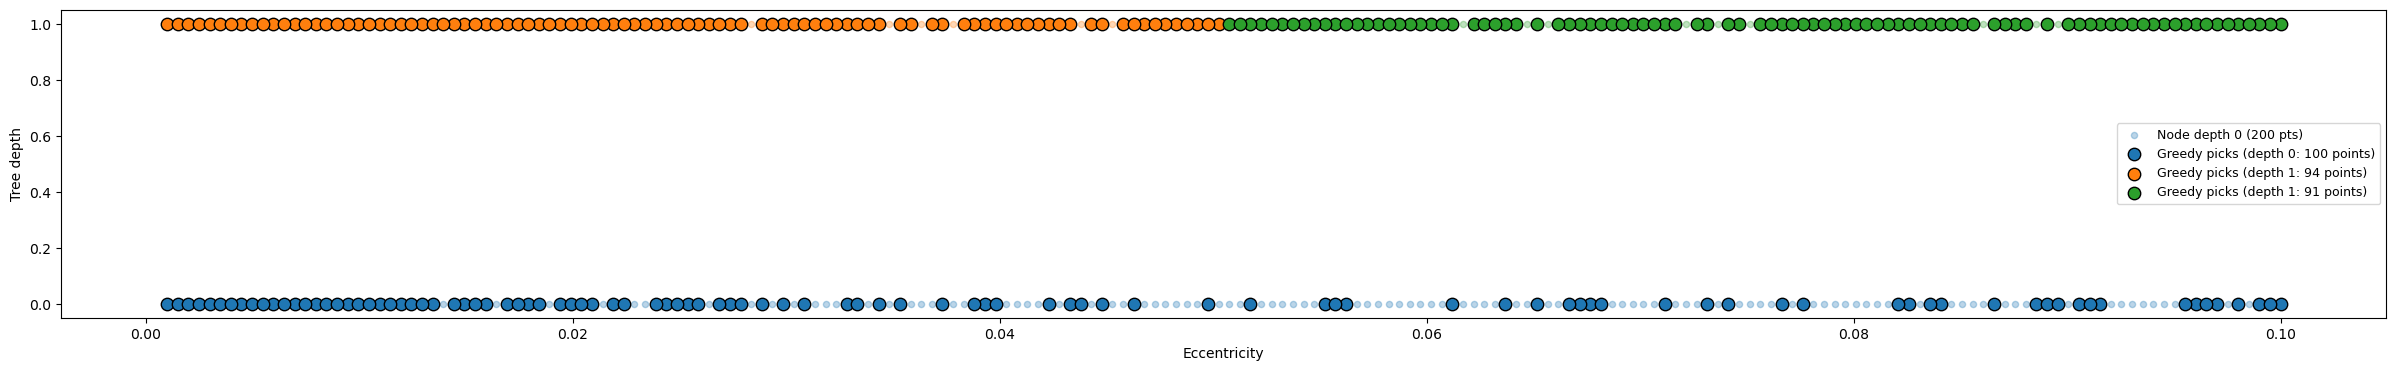

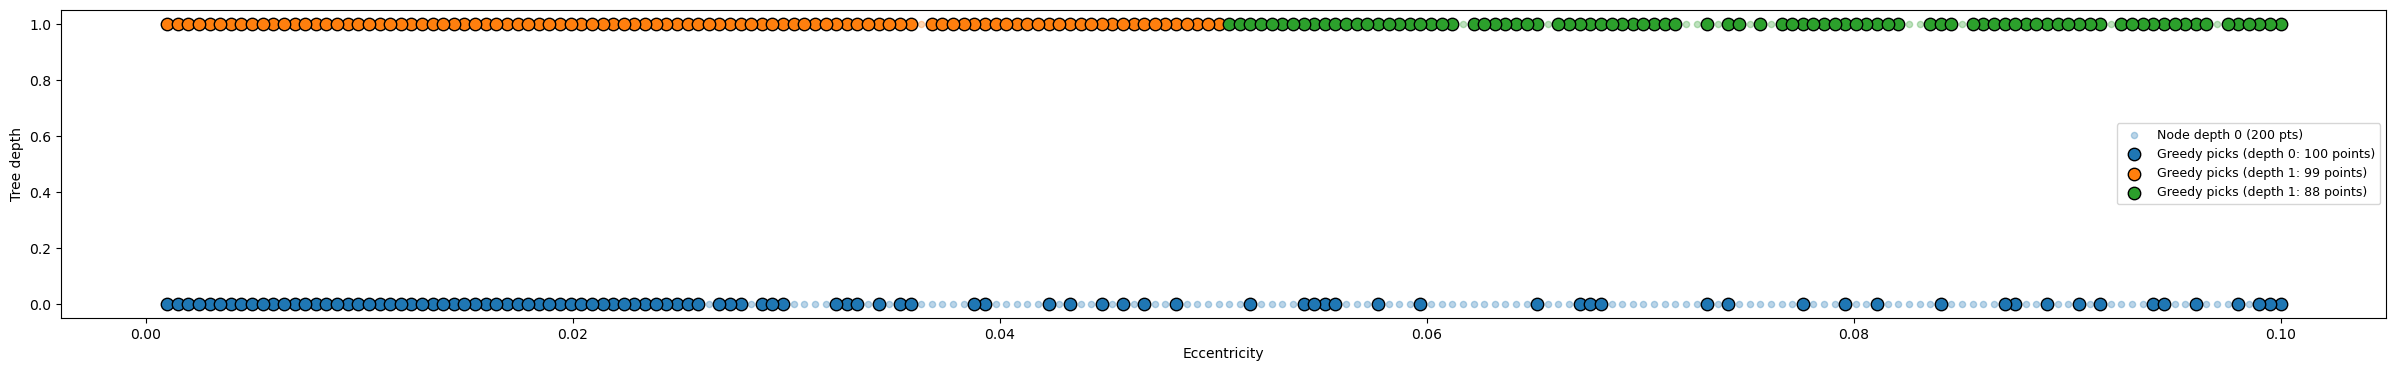

In [41]:
def plot_splits_1D(node, depth=0, ax=None, color='C0'):
    """
    Recursively plot a 1D reduced-basis tree along eccentricity.
    
    Parameters
    ----------
    node : Node
        Node of the reduced-basis tree.
    depth : int
        Current depth in the tree.
    ax : matplotlib.axes.Axes, optional
        Axis to plot on.
    color : str
        Color for the greedy basis points at this node.
    
    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(30,4))

    x = node.train_parameters
    
    # all training points (faded)
    ax.scatter(x, [depth]*len(x), s=20, alpha=0.3, label=f"Node depth {depth} ({len(x)} pts)" if depth==0 else "")
    
    # greedy-selected points
    greedy_params = x[node.indices]
    ax.scatter(greedy_params, [depth]*len(greedy_params), s=80, edgecolor='k', facecolor=color, label=f"Greedy picks (depth {depth}: {len(greedy_params)} points)")
    
    # recursively plot subspaces
    if hasattr(node, 'children') and node.children is not None:
        for i, child in enumerate(node.children):
            plot_splits_1D(child, depth+1, ax=ax, color=f"C{i+1}")
    else:
        # fallback for nodes using idxs_subspace0/1
        if hasattr(node, 'idxs_subspace0') and node.idxs_subspace0 is not None:
            child0 = node
            plot_splits_1D(child0, depth+1, ax=ax, color='C1')
        if hasattr(node, 'idxs_subspace1') and node.idxs_subspace1 is not None:
            child1 = node
            plot_splits_1D(child1, depth+1, ax=ax, color='C2')
    
    ax.set_xlabel("Eccentricity")
    ax.set_ylabel("Tree depth")
    ax.legend(fontsize=9)
    
    return ax
plt.close('all')
# Example usage:
ax = plot_splits_1D(rb_amp_norm_l.tree)
ax = plot_splits_1D(rb_phase_norm_l.tree)
plt.show()



In [25]:
def all_greedy_errors(node):
    # if leaf node
    if hasattr(node, "errors"):
        return node.errors
    # otherwise, concatenate the errors of children
    errs = []
    if hasattr(node, "children"):
        print(f"Node has {len(node.children)} children, traversing...")
        for child in node.children:
            errs = np.hstack([errs, all_greedy_errors(child)])
            print(f"Collected errors from child, total length now: {len(all_greedy_errors(child))}")
    return errs

amplitude_errors_norm_l = all_greedy_errors(rb_amp_norm_l.tree)
phase_errors_norm_l = all_greedy_errors(rb_phase_norm_l.tree)

# amplitude_errors_norm_l = rb_amp_norm_l.tree.errors
# phase_errors_norm_l = rb_phase_norm_l.tree.errors

print("Max amplitude error:", np.max(amplitude_errors_norm_l))
print("Max phase error:", np.max(phase_errors_norm_l))

fig, ax = plt.subplots(2, 1, figsize=(12,6))
ax[0].plot(np.arange(len(amplitude_errors_norm_l)), amplitude_errors_norm_l, label='greedy error for amplitude, lmax='+str(rb_amp_norm_l.lmax), lw=1.8, color='blue')
ax[0].set_yscale('log')
ax[0].set_ylabel('Greedy error')
ax[0].legend()

ax[1].plot(np.arange(len(amplitude_errors_norm)), amplitude_errors_norm, label='greedy error for amplitude, lmax='+str(rb_amp_norm.lmax), lw=1.8, color='blue')
ax[1].set_xlabel('# of greedy vectors')
ax[1].set_yscale('log')
ax[1].set_ylabel('Greedy error')
ax[1].legend()


plt.figure(figsize=(12,3))
plt.plot(np.arange(len(phase_errors_norm_l)), phase_errors_norm_l, label='greedy error for phase, lmax='+str(rb_phase_norm_l.lmax), lw=1.8, color='blue')
plt.xlabel('# of greedy vectors')
plt.yscale('log')
plt.legend()
\
print(rb_amp_norm_l.lmax)

Node has 2 children, traversing...
Collected errors from child, total length now: 94
Collected errors from child, total length now: 91
Node has 2 children, traversing...
Collected errors from child, total length now: 99
Collected errors from child, total length now: 88
Max amplitude error: 0.45253919230461626
Max phase error: 0.6279194422392929
4


Upper plot: The greedy error is calculated for two seperate sections, this shows the two seperate regions undergoing exponential decay. 

The final drop to extremely small values occurs when the dataset becomes fully representable by the constructed basis (up to numerical precision).

### Empirical interpolation

In [42]:
emp_nodes_idx_phase, rb_phase_norm = get_empirical_nodes(rb_phase_norm_l)
print('\n')
emp_nodes_idx_amp, rb_amp_norm = get_empirical_nodes(rb_amp_norm_l)

Empirical nodes: [ 124 8117 6496 7589  252 8132 8136 6381 6555 8134 7724 6355 8141 6414
 8137 6590 6459 8135 6520 8133 8115 8131 6433  615  400 8121 6477 1355
 6315 1936 6068 8081 6242 8120 6396 2066 1016 8130 8122 8084 6719 8088
  838 5758 6613 1590 8138 8118 8145 7330 7623 6535 8086 1786 5974 7126
 6573 6276 6831 7694 8119  729 6757 2305 6644 8111 8123 5540 5626 8116
 1257 8139 8107 5454 8028 6336 6488 3699 8072 8042 8129 6468 6626 6162
 2389 7489 5172 6295 7747 1459 6189 1104 3038 7686 8085 6506 2650 8124
 5936] 
length of empirical nodes: 99 
length of reduced basis: 99
Empirical nodes: [7977  144  231 2113 7662 6529   90 6501 6409 6579 6550 8121 6431 8134
 7694 8132 6621 8085 8076 6388 6473 6339 6487 6764 8136 8140  189 6450
 8122 6073 7751  538 1868 8082 6650 8088 6565 8133 6823 6365 8116  358
 6292 8120 8138 8131 3673 5996 6517 2453 5926 8135 1588 6690 8118 1745
 7612 6320 6873 6248 8119 8123 3127 8095 6152 7368  858 6606 4449 6792
 3362 5751 8113 4189 2851 8130 7402 6421 8117  

In [26]:
emp_nodes_idx_phase, rb_phase_norm = get_empirical_nodes(rb_phase_norm)
print('\n')
emp_nodes_idx_amp, rb_amp_norm = get_empirical_nodes(rb_amp_norm)

Empirical nodes: [ 124 7966 2680 6496 7590  241 8132 6526 6381 8136 6354 7725 8134 8141
 6414 6591  358  183 5933 2108 8137 6430 8083 8115  871 8117 8121 8135
 6451 8133 6560 6475 1876 8120 8085 6620 6512 6277 1768 8131 7703 6398
 8122 1342  716 6701 6818 8119 5765 8079 8130 6143 5985 1102 7105 8037
 1966 8138  521  585 7327 8088 6543 8112 6301 7680 7618 8116 6752 8139
 1244 4372 8068 6605  970 6654 8123 6066 2283  282 8086 5521 8118 6463
 6885 6180 7545 8129  438 6327 5235 8099 6676 6248 5188 1650 5824 6575
 6637 8145] 
length of empirical nodes: 100 
length of reduced basis: 100


Empirical nodes: [  21  298 1782  174  222 8084 8086 8132 8134 8145 8135 8090 7590  131
 8137 6381 7714  257 8081 7691 6488 8140 8120 6419 8136 8115 8076 8131
  366 6517 8121 8117 8074 8133 8085 8049 6399 8130 8144 6587 6461 8094
 8118 4101 8122 8028 6502 8119   99 8139 8097 8112 6226 7740 8142 2530
 6359 8088 6442 7170 8108 8129 7764 8083 6546 8123 3307 6718  487 5897
 8126 6564 6299 8141 8100 6620 8071 80

In [27]:
V_phase = plot_interpolation_matrix(rb_phase_norm)
V_amp = plot_interpolation_matrix(rb_amp_norm)

print(np.linalg.cond(V_phase))
print(np.linalg.cond(V_amp))

146.54967742069718
134.14565863589414


The empirical interpolation reconstruction error decreases steadily as additional nodes are included, confirming that each node captures new independent structure in the phase residuals. The error drops by roughly three orders of magnitude and reaches a plateau near $10^{-3}$ once about 15–20 nodes are used. This indicates that the dominant residual structure is captured by the first few nodes, while later nodes account for progressively smaller corrections. The plateau suggests that the remaining error is primarily due to reduced-basis truncation rather than limitations of the empirical interpolation itself.


In [28]:
proj_errors_phase, eim_errors_phase = plot_projection_error_vs_eim_error(rb_phase_norm, res_ds_phase)
proj_errors_amp, eim_errors_amp = plot_projection_error_vs_eim_error(rb_amp_norm, res_ds_amp)

In [29]:
plot_error_ratio(rb_phase_norm, proj_errors_phase, eim_errors_phase)
plot_error_ratio(rb_amp_norm, proj_errors_amp, eim_errors_amp)


To assess the quality of the empirical interpolation rule, the EIM reconstruction error was compared to the optimal projection error obtained in the same reduced basis. The projection error represents the best possible approximation achievable with the first \(k\) basis modes, while the EIM error measures the accuracy when the coefficients are reconstructed using only waveform values at the empirical nodes.

The two curves show similar decay, indicating that the empirical nodes preserve most of the information contained in the reduced basis. The interpolation overhead, measured as the ratio between the EIM error and projection error, remains within a factor of a few across the full basis size. This demonstrates that the empirical node selection provides an efficient interpolation rule that introduces only modest additional error beyond the intrinsic reduced-basis approximation.


In [30]:
plot_nodes_on_rb_functions(rb_phase_norm, gt.time)
plot_nodes_on_rb_functions(rb_amp_norm, gt.time)

## Normalised, weighted

In [31]:
plt.figure(figsize=(12,3))
plt.plot(ecc_ref_parameterspace, np.zeros(len(ecc_ref_parameterspace)), label='eccentricity parameter space', lw=1.8, color='gray')
plt.scatter(amplitude_parameters, np.zeros(len(amplitude_parameters)), label='greedy parameters for amplitude', color='red', s=20)
plt.xlabel('eccentricity')
plt.legend()

plt.figure(figsize=(12,3))
plt.plot(ecc_ref_parameterspace, np.zeros(len(ecc_ref_parameterspace)), label='eccentricity parameter space', lw=1.8, color='gray')
plt.scatter(phase_parameters, np.zeros(len(phase_parameters)), label='greedy parameters for phase', color='blue', s=20)
plt.xlabel('eccentricity')
plt.legend()


In [32]:
amplitude_errors = rb_amp.tree.errors
phase_errors = rb_phase.tree.errors

print("Max, min amplitude error:", np.max(amplitude_errors), np.min(amplitude_errors))
print("Max, min phase error:", np.max(phase_errors), np.min(phase_errors))

plt.figure(figsize=(12,3))
plt.plot(amplitude_parameters, amplitude_errors, label='greedy error for amplitude', lw=1.8, color='red')
plt.xlabel('# of greedy vectors')
plt.legend()

plt.figure(figsize=(12,3))
plt.plot(phase_parameters, phase_errors, label='greedy error for phase', lw=1.8, color='blue')
plt.xlabel('# of greedy vectors')
plt.legend()

Max, min amplitude error: 0.5097930891309514 8.965936762222673e-10
Max, min phase error: 226964.50759560766 8.485122166775449e-06


### Empirical interpolation

In [33]:
def get_empirical_nodes(rb):
    eim = EmpiricalInterpolation(rb)
    eim.fit()

    # print('Amount of leaves in reduced basis tree:', len(rb.tree.leaves))
    dir(rb.tree.leaves[0])

    for i in range(len(rb.tree.leaves)):
        emp_nodes_idx = rb.tree.leaves[i].empirical_nodes
        emp_nodes_idx = np.array(emp_nodes_idx).astype(int)
    
        print('Empirical nodes:', emp_nodes_idx,
            '\nlength of empirical nodes:', len(emp_nodes_idx),
            '\nlength of reduced basis:', len(rb.tree.leaves[i].indices)) # .indices refers to the indices of the greedy basis vectors
        
    return emp_nodes_idx, rb

emp_nodes_idx_phase, rb_phase = get_empirical_nodes(rb_phase)
print('\n')
emp_nodes_idx_amp, rb_amp = get_empirical_nodes(rb_amp)

Empirical nodes: [ 124 7966 3050  218 6500 6567  169 6411 6540 8132 7598 6434 6381 7692
 6077  284 8134 6460 6617 7722 6518  956 8137 8087 8080 7757 8135 6477
 8075 6584 6359 7635 6299  513  665 6757  340 8119 6821 8133 8120 1661
 6446 1962 5889 8121] 
length of empirical nodes: 46 
length of reduced basis: 46


Empirical nodes: [  21  298 2182  161  207 8085 8140 7602  121 8134  255 8089 5970 8132
 7647 7732 8077 8094 8082 8074 8136  362 6438 6412] 
length of empirical nodes: 24 
length of reduced basis: 24


In [34]:
fig_eim, axs =plt.subplots(2, 1, figsize=(20,6))

axs[0].scatter(gt.time[emp_nodes_idx_phase],res_ds_phase[-1][emp_nodes_idx_phase], label='empirical nodes for phase', color='blue')
axs[0].plot(gt.time, res_ds_phase[-1], label='phase at max eccentricity', lw=1.8, color='gray')
axs[0].set_xlabel('time [M]')
axs[0].set_ylabel('phase [rad]')

axs[1].scatter(gt.time[emp_nodes_idx_amp], res_ds_amp[-1][emp_nodes_idx_amp], label='empirical nodes for amplitude', color='red', s=20)
axs[1].plot(gt.time, res_ds_amp[-1], label='amplitude at max eccentricity', lw=1.8, color='gray')
axs[1].set_xlabel('time [M]')
axs[1].set_ylabel('amplitude ')

axs[0].legend()
axs[1].legend()



# Considerations in greedy basis method

### Motivations for selecting greedy basis methods

- **Parameter estimation/template banks/injection studies:** Waveforms with higher SNR should contribute more and preferably be more precise --> high eccentricity has more high-freq power. Use *weights dependent on SNR/likelihood* outcome (PSD weighted). 
- **Astrophysical bias:** high-ecc systems are more rare than low-ecc ones --> higher accuracy in low ecc domain. Choose *weights dependent on (current detector) population* studies.
- **Regression difficulty:** High-ecc domain is harder to fit, so should be prioritised for the best overall result. 
    - Possibly *weighting on the gradient of the parameter space.*
    - Choose the next point based on the worst estimated part of parameter space, *minimizing residual fit errors*.
    - Run unweighted normalised greedy and compute final per-waveform residuals. *Weight afterwards based on largest residual error* and build a new basis adding weighted difficulty.

    $$ w_i = 1 + \alpha \frac{\varepsilon_i}{\max(\varepsilon)} $$
    - Apply *descritized parameter space regions* (trees: already an option in `scikit-reducedmodel` package) based on max greedy error to prevent under-representation of certain areas which could lead to inprecise fitting.

- **Uniform parameter volume:** Build the basis so the *waveform volume is uniform distributed*. Uniformly picked parameter space values do not result in a uniform residual difference between waveforms (amps and phases). High-ecc regions change more rapidly. --> Sample more in high-ecc region, based on residual volume. 

| Use case                  | Goal                     | Weighted modification                        |
|---------------------------|----------------------------------|----------------------------------------|
| Parameter estimation      | Likelihood mismatch              | Change inner product (PSD-weighted)    |
| Uniform surrogate         | Equal parameter coverage         | Density weighting                     |
| Hard fitting region       | Local curvature / complexity     | Residual-based weighting               |
| Astrophysical realism     | Expected physical population     | Prior weighting                        |


Check dephasing effect by looking at the mismatch in low vs high ecc

# Higher-dimensional basis

Add mass-ratio to the dimensions

In [ ]:
sampling_frequency = 2048 # or 4096
duration = 4 # seconds
time_array = np.linspace(-duration, 0, int(sampling_frequency * duration))  # time in seconds
print(f'time-array: [{round(SecondtoMass(time_array, 60)[0], 2)}, {round(SecondtoMass(time_array, 60)[-1], 2)}] seconds, with {len(time_array)} points')
ecc_ref_parameterspace=np.linspace(0.001, 0.1, num=200)

gt = Generate_TrainingSet(time_array=time_array, ecc_ref_parameterspace=ecc_ref_parameterspace, mean_ano_parameterspace=[0], N_basis_vecs_amp=20, N_basis_vecs_phase=20,
                          minimum_spacing_greedy=0.003 )
res_ds_phase = gt.generate_property_dataset(property='phase', ecc_ref_list=ecc_ref_parameterspace, plot_residuals_time_evolv=True, plot_residuals_eccentric_evolv=True, show_legend=False)
res_ds_amp = gt.generate_property_dataset(property='amplitude', ecc_ref_list=ecc_ref_parameterspace, plot_residuals_time_evolv=True, plot_residuals_eccentric_evolv=True, show_legend=False)


# Eccentric surrogate model development

In [35]:
sampling_frequency = 2048 # or 4096
duration = 4 # seconds
time_array = np.linspace(-duration, 0, int(sampling_frequency * duration))  # time in seconds
print(f'time-array: [{round(SecondtoMass(time_array, 60)[0], 2)}, {round(SecondtoMass(time_array, 60)[-1], 2)}] seconds, with {len(time_array)} points')
ecc_ref_parameterspace=np.linspace(0.001, 0.1, num=200)

gt = Generate_TrainingSet(time_array=time_array, ecc_ref_parameterspace=ecc_ref_parameterspace, mean_ano_parameterspace=[0], N_basis_vecs_amp=20, N_basis_vecs_phase=20,
                          minimum_spacing_greedy=0.003 )




time-array: [-13535.03, 0.0] seconds, with 8192 points


In [36]:
res_ds_phase = gt.generate_property_dataset('phase', plot_residuals_time_evolv=True, plot_residuals_eccentric_evolv=True, show_legend=False)
res_ds_amp = gt.generate_property_dataset('amplitude', plot_residuals_time_evolv=True, plot_residuals_eccentric_evolv=True, show_legend=False)

[0.001      0.00149749 0.00199497 0.00249246 0.00298995 0.00348744
 0.00398492 0.00448241 0.0049799  0.00547739 0.00597487 0.00647236
 0.00696985 0.00746734 0.00796482 0.00846231 0.0089598  0.00945729
 0.00995477 0.01045226 0.01094975 0.01144724 0.01194472 0.01244221
 0.0129397  0.01343719 0.01393467 0.01443216 0.01492965 0.01542714
 0.01592462 0.01642211 0.0169196  0.01741709 0.01791457 0.01841206
 0.01890955 0.01940704 0.01990452 0.02040201 0.0208995  0.02139698
 0.02189447 0.02239196 0.02288945 0.02338693 0.02388442 0.02438191
 0.0248794  0.02537688 0.02587437 0.02637186 0.02686935 0.02736683
 0.02786432 0.02836181 0.0288593  0.02935678 0.02985427 0.03035176
 0.03084925 0.03134673 0.03184422 0.03234171 0.0328392  0.03333668
 0.03383417 0.03433166 0.03482915 0.03532663 0.03582412 0.03632161
 0.0368191  0.03731658 0.03781407 0.03831156 0.03880905 0.03930653
 0.03980402 0.04030151 0.04079899 0.04129648 0.04179397 0.04229146
 0.04278894 0.04328643 0.04378392 0.04428141 0.04477889 0.0452

In [37]:
gt.get_greedy_parameters(U=res_ds_phase, property='phase', N_greedy_vecs=20, plot_greedy_error=True, save_greedy_error_fig=True, plot_greedy_vectors=True, save_greedy_vecs_fig=True)
gt.get_greedy_parameters(U=res_ds_amp, property='amplitude', N_greedy_vecs=20, plot_greedy_error=True, save_greedy_error_fig=True, plot_greedy_vectors=True, save_greedy_vecs_fig=True)


phase
Greedy error fig saved to Images/Greedy_errors/Greedy_error_phase_M=60_ecc=[0.001_0.1]_f_lower=10_f_ref=20_iN=200_gerr=0.0003713538782322908_ms=0.003.png
Number of child nodes: 1
Greedy vectors fig saved to Images/Greedy_vectors/Greedy_vectors_phase_M=60_ecc=[0.001_0.1]_f_lower=10_f_ref=20_iN=200_ms=0.003.png
amplitude
Greedy error fig saved to Images/Greedy_errors/Greedy_error_amplitude_M=60_ecc=[0.001_0.1]_f_lower=10_f_ref=20_iN=200_gerr=0.0002951276803662676_ms=0.003.png
Number of child nodes: 1
Greedy vectors fig saved to Images/Greedy_vectors/Greedy_vectors_amplitude_M=60_ecc=[0.001_0.1]_f_lower=10_f_ref=20_iN=200_ms=0.003.png
